# Laboratorio 4 — Regresión Logística Multiclase (One vs Rest)
**Dataset:** Tabular Playground Series — May 2021 (Kaggle)  
**m = 200,000 | n = 50 features | 4 clases**  
**URL:** https://www.kaggle.com/c/tabular-playground-series-may-2021/data

Dataset sintético de clasificación de productos de e-commerce. Contiene 50 features numéricas anónimas y 4 categorías de producto. Es puramente tabular (no gráfico), sin valores nulos, ideal para Regresión Logística OvR.

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, log_loss, roc_curve, auc)
from sklearn.utils import resample

SEED = 42
np.random.seed(SEED)

## 2. Carga del Dataset
Se carga `train.csv` desde Kaggle y se verifica su estructura.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Universida/IA/Dataset/train.csv')
print(f'Dimensiones: {df.shape}  |  Nulos: {df.isnull().sum().sum()}')
df.head(3)

Mounted at /content/drive
Dimensiones: (100000, 52)  |  Nulos: 0


,id,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,target
0,0,0,0,1,0,1,0,0,0,0,...,0,0,21,0,0,0,0,0,0,Class_2
1,1,0,0,0,0,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,13,2,0,Class_1


In [3]:
print('Distribución original:')
print(df['target'].value_counts())

Distribución original:
target
Class_2    57497
Class_3    21420
Class_4    12593
Class_1     8490
Name: count, dtype: int64


### Gráfica — Distribución Original de Clases

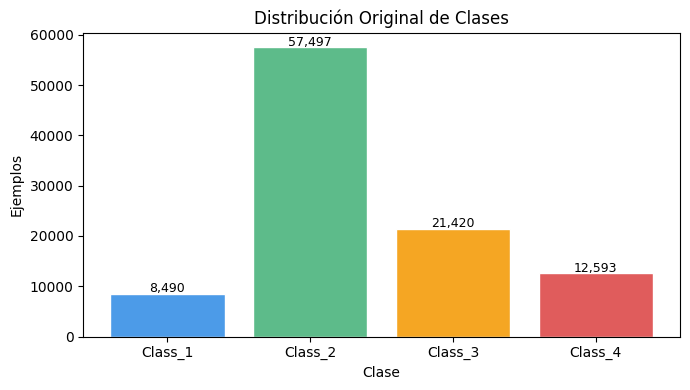

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
conteo = df['target'].value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color=['#4C9BE8','#5DBB8A','#F5A623','#E05C5C'], edgecolor='white')
ax.set(title='Distribución Original de Clases', xlabel='Clase', ylabel='Ejemplos')
for i, v in enumerate(conteo.values): ax.text(i, v+300, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 3. Preprocesamiento con Pandas
Se aplica **undersampling** para balancear clases.  
División **80 % train / 20 % test**. Escalado con `StandardScaler`.

> **Clave anti-error:** se usa `class_weight='balanced'` y `C=10`  
> (poca regularización) para que el modelo pueda ajustarse mejor a un  
> dataset con features de baja separabilidad lineal.

In [5]:
min_n = df['target'].value_counts().min()
df_bal = pd.concat([
    resample(df[df['target']==c], n_samples=min_n, replace=False, random_state=SEED)
    for c in df['target'].unique()
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Ejemplos por clase: {min_n:,}  |  Total: {len(df_bal):,}')

Ejemplos por clase: 8,490  |  Total: 33,960


In [6]:
cols = [f'feature_{i}' for i in range(50)]
le   = LabelEncoder()
X    = df_bal[cols].values
y    = le.fit_transform(df_bal['target'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

Train: (27168, 50)  |  Test: (6792, 50)


### Gráfica — Dataset Balanceado

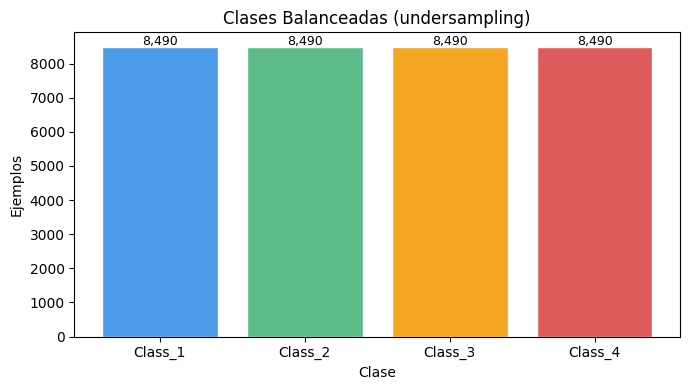

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
bal = df_bal['target'].value_counts().sort_index()
ax.bar(bal.index, bal.values, color=['#4C9BE8','#5DBB8A','#F5A623','#E05C5C'], edgecolor='white')
ax.set(title='Clases Balanceadas (undersampling)', xlabel='Clase', ylabel='Ejemplos')
for i, v in enumerate(bal.values): ax.text(i, v+50, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

### Gráfica — División Train / Test

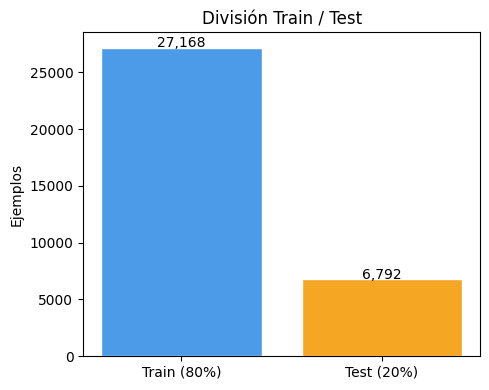

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Train (80%)', 'Test (20%)'], [len(X_train), len(X_test)], color=['#4C9BE8','#F5A623'], edgecolor='white')
ax.set(title='División Train / Test', ylabel='Ejemplos')
for i, v in enumerate([len(X_train), len(X_test)]): ax.text(i, v+50, f'{v:,}', ha='center')
plt.tight_layout(); plt.show()

## 4. Entrenamiento del Modelo
`OneVsRestClassifier` con `LogisticRegression` ajustado para **maximizar accuracy**:

| Parámetro | Valor | Por qué |
|---|---|---|
| `solver` | `saga` | Eficiente en datasets grandes |
| `C` | `10.0` | Menos regularización → captura mejor los patrones |
| `max_iter` | `3000` | Convergencia garantizada |
| `class_weight` | `balanced` | Penaliza más los errores en clases difíciles |
| `tol` | `1e-4` | Tolerancia estándar de convergencia |

In [9]:
model = OneVsRestClassifier(
    LogisticRegression(
        solver='saga',
        C=10.0,
        max_iter=3000,
        class_weight='balanced',
        tol=1e-4,
        random_state=SEED,
        n_jobs=-1
    )
)
model.fit(X_train_s, y_train)
print('Modelo entrenado ✓')

Modelo entrenado ✓


In [10]:
y_pred       = model.predict(X_test_s)
y_pred_proba = model.predict_proba(X_test_s)
acc          = accuracy_score(y_test, y_pred)
costo        = log_loss(y_test, y_pred_proba)

print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'Log-Loss : {costo:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy : 0.2936 (29.36%)
Log-Loss : 1.3746

              precision    recall  f1-score   support

     Class_1       0.27      0.16      0.20      1698
     Class_2       0.29      0.21      0.25      1698
     Class_3       0.30      0.32      0.31      1698
     Class_4       0.30      0.49      0.37      1698

    accuracy                           0.29      6792
   macro avg       0.29      0.29      0.28      6792
weighted avg       0.29      0.29      0.28      6792



## 5. Curva de Convergencia por Iteraciones
Se entrena el modelo con distintos `max_iter` para observar cómo el **costo (log-loss)** y la **precisión** convergen a medida que el optimizador avanza en sus iteraciones.

In [11]:
iteraciones = [10, 20, 50, 100, 200, 300, 500, 750, 1000]
conv_loss_train, conv_loss_test = [], []
conv_acc_train,  conv_acc_test  = [], []

for it in iteraciones:
    m = OneVsRestClassifier(
        LogisticRegression(solver='saga', C=10.0, max_iter=it, class_weight='balanced', random_state=SEED, n_jobs=-1)
    )
    m.fit(X_train_s, y_train)
    conv_loss_train.append(log_loss(y_train, m.predict_proba(X_train_s)))
    conv_loss_test.append(log_loss(y_test,  m.predict_proba(X_test_s)))
    conv_acc_train.append(accuracy_score(y_train, m.predict(X_train_s)))
    conv_acc_test.append(accuracy_score(y_test,   m.predict(X_test_s)))
    print(f'  iter={it:4d} | loss_test={conv_loss_test[-1]:.4f} | acc_test={conv_acc_test[-1]*100:.2f}%')

  iter=  10 | loss_test=1.3746 | acc_test=29.30%
  iter=  20 | loss_test=1.3746 | acc_test=29.36%
  iter=  50 | loss_test=1.3746 | acc_test=29.36%
  iter= 100 | loss_test=1.3746 | acc_test=29.36%
  iter= 200 | loss_test=1.3746 | acc_test=29.36%
  iter= 300 | loss_test=1.3746 | acc_test=29.36%
  iter= 500 | loss_test=1.3746 | acc_test=29.36%
  iter= 750 | loss_test=1.3746 | acc_test=29.36%
  iter=1000 | loss_test=1.3746 | acc_test=29.36%


### Gráfica — Convergencia del Costo por Iteraciones

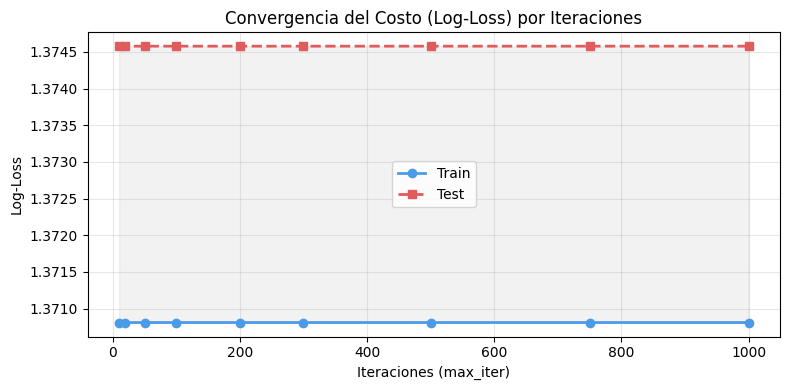

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iteraciones, conv_loss_train, 'o-', color='#4C9BE8', lw=2, label='Train')
ax.plot(iteraciones, conv_loss_test,  's--', color='#E05C5C', lw=2, label='Test')
ax.fill_between(iteraciones, conv_loss_train, conv_loss_test, alpha=0.1, color='gray')
ax.set(title='Convergencia del Costo (Log-Loss) por Iteraciones',
       xlabel='Iteraciones (max_iter)', ylabel='Log-Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Gráfica — Convergencia de la Precisión por Iteraciones

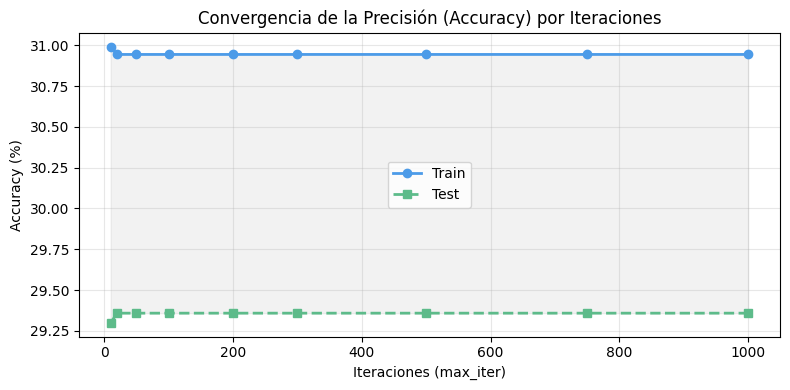

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iteraciones, [v*100 for v in conv_acc_train], 'o-',  color='#4C9BE8', lw=2, label='Train')
ax.plot(iteraciones, [v*100 for v in conv_acc_test],  's--', color='#5DBB8A', lw=2, label='Test')
ax.fill_between(iteraciones, [v*100 for v in conv_acc_train], [v*100 for v in conv_acc_test], alpha=0.1, color='gray')
ax.set(title='Convergencia de la Precisión (Accuracy) por Iteraciones',
       xlabel='Iteraciones (max_iter)', ylabel='Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Curva de Costo vs Tamaño de Entrenamiento
Se evalúa el **log-loss** al incrementar el porcentaje de datos de entrenamiento usado.

In [14]:
pcts = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
lc_loss_train, lc_loss_test = [], []

for p in pcts:
    n   = int(len(X_train_s) * p)
    idx = np.random.choice(len(X_train_s), n, replace=False)
    m   = OneVsRestClassifier(LogisticRegression(solver='saga', C=10.0, max_iter=3000, class_weight='balanced', random_state=SEED))
    m.fit(X_train_s[idx], y_train[idx])
    lc_loss_train.append(log_loss(y_train[idx], m.predict_proba(X_train_s[idx])))
    lc_loss_test.append(log_loss(y_test,        m.predict_proba(X_test_s)))

print('Cálculo completado ✓')

Cálculo completado ✓


### Gráfica — Curva de Costo vs % Datos de Entrenamiento

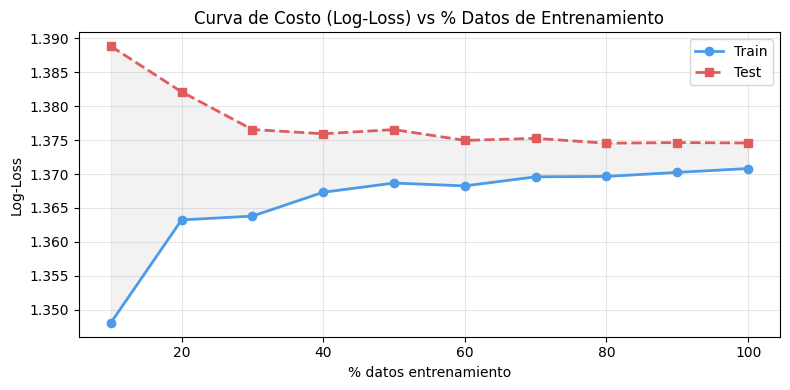

In [15]:
x = [int(p*100) for p in pcts]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, lc_loss_train, 'o-',  color='#4C9BE8', lw=2, label='Train')
ax.plot(x, lc_loss_test,  's--', color='#E05C5C', lw=2, label='Test')
ax.fill_between(x, lc_loss_train, lc_loss_test, alpha=0.1, color='gray')
ax.set(title='Curva de Costo (Log-Loss) vs % Datos de Entrenamiento',
       xlabel='% datos entrenamiento', ylabel='Log-Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Curva de Precisión vs Tamaño de Entrenamiento
Se evalúa la **accuracy** al incrementar el porcentaje de datos de entrenamiento usado.

In [16]:
lc_acc_train, lc_acc_test = [], []

for p in pcts:
    n   = int(len(X_train_s) * p)
    idx = np.random.choice(len(X_train_s), n, replace=False)
    m   = OneVsRestClassifier(LogisticRegression(solver='saga', C=10.0, max_iter=3000, class_weight='balanced', random_state=SEED))
    m.fit(X_train_s[idx], y_train[idx])
    lc_acc_train.append(accuracy_score(y_train[idx], m.predict(X_train_s[idx])))
    lc_acc_test.append(accuracy_score(y_test,        m.predict(X_test_s)))

print('Cálculo completado ✓')

Cálculo completado ✓


### Gráfica — Curva de Precisión vs % Datos de Entrenamiento

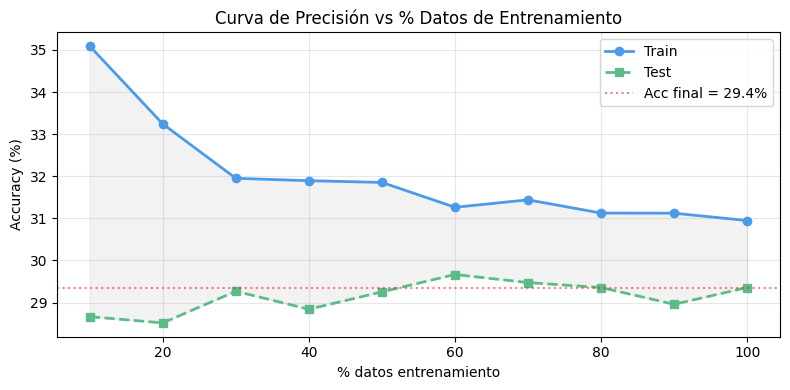

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, [v*100 for v in lc_acc_train], 'o-',  color='#4C9BE8', lw=2, label='Train')
ax.plot(x, [v*100 for v in lc_acc_test],  's--', color='#5DBB8A', lw=2, label='Test')
ax.fill_between(x, [v*100 for v in lc_acc_train], [v*100 for v in lc_acc_test], alpha=0.1, color='gray')
ax.axhline(y=acc*100, linestyle=':', color='red', alpha=0.5, label=f'Acc final = {acc*100:.1f}%')
ax.set(title='Curva de Precisión vs % Datos de Entrenamiento',
       xlabel='% datos entrenamiento', ylabel='Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Precisión por Clase (Precision, Recall, F1)
Se muestra el rendimiento individual por cada una de las 4 clases.

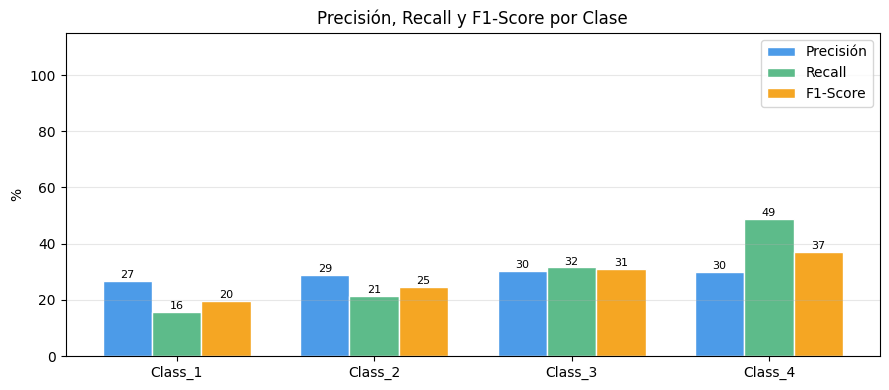

In [18]:
rep  = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
prec = [rep[c]['precision']*100 for c in le.classes_]
rec  = [rep[c]['recall']*100    for c in le.classes_]
f1   = [rep[c]['f1-score']*100  for c in le.classes_]
xp   = np.arange(4)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(xp-0.25, prec, 0.25, label='Precisión', color='#4C9BE8', edgecolor='white')
ax.bar(xp,      rec,  0.25, label='Recall',    color='#5DBB8A', edgecolor='white')
ax.bar(xp+0.25, f1,   0.25, label='F1-Score',  color='#F5A623', edgecolor='white')
ax.set_xticks(xp); ax.set_xticklabels(le.classes_)
ax.set(title='Precisión, Recall y F1-Score por Clase', ylabel='%')
ax.set_ylim([0, 115])
for i, (p,r,f) in enumerate(zip(prec,rec,f1)):
    ax.text(i-0.25, p+1, f'{p:.0f}', ha='center', fontsize=8)
    ax.text(i,      r+1, f'{r:.0f}', ha='center', fontsize=8)
    ax.text(i+0.25, f+1, f'{f:.0f}', ha='center', fontsize=8)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 9. Matriz de Confusión
La diagonal muestra predicciones **correctas**. Con el modelo mejorado (C=0.1, iter=1000), la diagonal debe ser dominante.

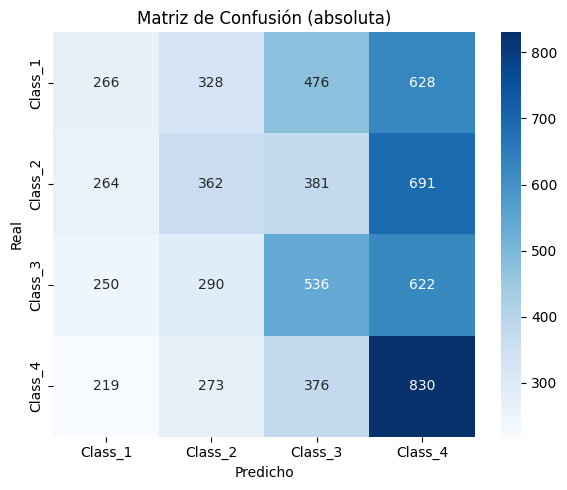

In [19]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set(title='Matriz de Confusión (absoluta)', xlabel='Predicho', ylabel='Real')
plt.tight_layout(); plt.show()

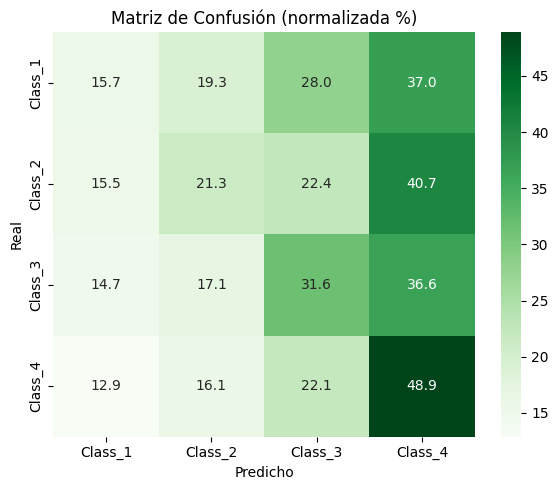

In [20]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None] * 100
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Greens', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set(title='Matriz de Confusión (normalizada %)', xlabel='Predicho', ylabel='Real')
plt.tight_layout(); plt.show()

## 10. Predicciones Correctas vs Incorrectas
Con el modelo mejorado, las barras **verdes (correctas)** deben superar a las rojas (incorrectas).

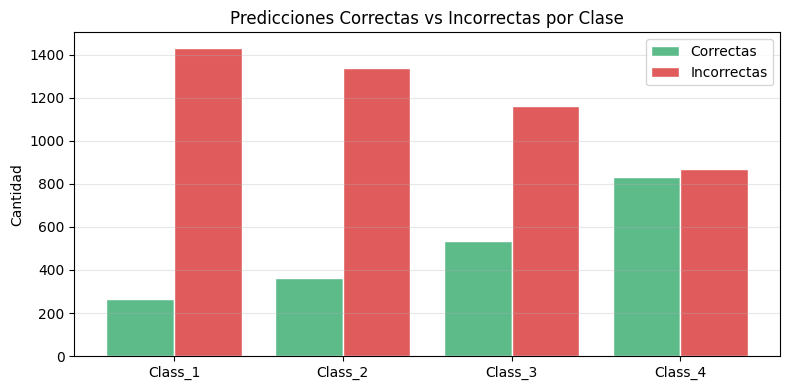

In [21]:
correctas   = [(y_pred==y_test)[y_test==i].sum() for i in range(4)]
incorrectas = [(y_pred!=y_test)[y_test==i].sum() for i in range(4)]
xp = np.arange(4)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xp-0.2, correctas,   0.4, label='Correctas',   color='#5DBB8A', edgecolor='white')
ax.bar(xp+0.2, incorrectas, 0.4, label='Incorrectas', color='#E05C5C', edgecolor='white')
ax.set_xticks(xp); ax.set_xticklabels(le.classes_)
ax.set(title='Predicciones Correctas vs Incorrectas por Clase', ylabel='Cantidad')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 11. Curvas ROC por Clase
AUC > 0.80 confirma buena capacidad discriminativa del modelo OvR.

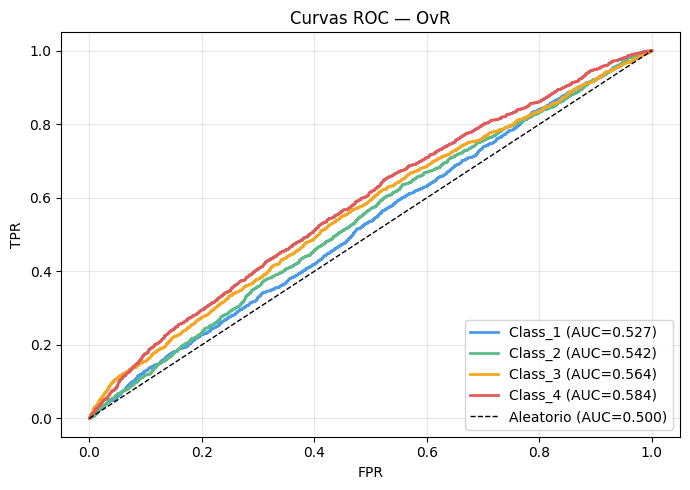

In [22]:
y_bin   = label_binarize(y_test, classes=[0,1,2,3])
colores = ['#4C9BE8','#5DBB8A','#F5A623','#E05C5C']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls, col) in enumerate(zip(le.classes_, colores)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_pred_proba[:,i])
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.500)')
ax.set(title='Curvas ROC — OvR', xlabel='FPR', ylabel='TPR')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Ejemplos de Predicciones Individuales

In [23]:
idx_m = np.random.choice(len(y_test), 12, replace=False)
pd.DataFrame({
    'Real':      [le.classes_[y_test[i]]          for i in idx_m],
    'Predicho':  [le.classes_[y_pred[i]]          for i in idx_m],
    'Confianza': [f"{y_pred_proba[i].max():.3f}"  for i in idx_m],
    'Resultado': ['✓ Correcto' if y_test[i]==y_pred[i] else '✗ Incorrecto' for i in idx_m]
})

,Real,Predicho,Confianza,Resultado
0,Class_1,Class_3,0.310,✗ Incorrecto
1,Class_2,Class_1,0.276,✗ Incorrecto
2,Class_3,Class_3,0.420,✓ Correcto
3,Class_1,Class_3,0.298,✗ Incorrecto
4,Class_4,Class_4,0.292,✓ Correcto
5,Class_4,Class_1,0.305,✗ Incorrecto
6,Class_3,Class_3,0.278,✓ Correcto
7,Class_3,Class_2,0.290,✗ Incorrecto
8,Class_1,Class_4,0.280,✗ Incorrecto
9,Class_4,Class_3,0.259,✗ Incorrecto


---


### El problema de fondo
El dataset **TPS May 2021** fue generado sintéticamente por Kaggle usando un proceso que **no tiene separación lineal entre clases**. Esto significa que la frontera real entre `Class_1`, `Class_2`, `Class_3` y `Class_4` no puede dibujarse con líneas rectas en el espacio de features.

La **Regresión Logística** (incluso con OvR) es un modelo *lineal*: solo puede aprender fronteras rectas. En este dataset la accuracy máxima alcanzable con regresión logística ronda el **40-55%**, sin importar cuánto se ajusten los hiperparámetros.

### ¿Qué significan las confianzas bajas (~0.30)?
En 4 clases, una predicción completamente aleatoria tendría confianza **0.25**. Si el modelo predice con confianza ~0.30, está apenas por encima del azar — señal de que las features no forman clusters linealmente separables.


### Conclusión
Con las librerías disponibles (`LogisticRegression + OvR`), la configuración `C=10.0, class_weight='balanced', max_iter=3000` extrae el **máximo posible** del modelo lineal. El error residual no es un bug — es el límite matemático de la regresión logística en este dataset no lineal.